# 라이브러리 불러오기

In [122]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import torchvision.transforms as transforms
import optuna
import numpy as np

# 데이터 평균 표준편차 구하기

In [14]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FlatImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        self.files = [f for f in os.listdir(root) if f.lower().endswith(exts)]
        if len(self.files) == 0:
            raise FileNotFoundError(f"No images found in: {root}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.root, self.files[idx])
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

root = r"C:\project\TEAM-PJ-DEEP\복만수\data1\train_4000"
dataset = FlatImageDataset(root, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

# ✅ 전체 픽셀 기준 누적합/제곱합
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in loader:  # images: (B,3,224,224)
    b, c, h, w = images.shape
    num_pixels += b * h * w
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])

mean = channel_sum / num_pixels
var = (channel_sq_sum / num_pixels) - (mean ** 2)
std = torch.sqrt(var)

print("mean:", mean)
print("std:", std)

mean: tensor([0.9367, 0.9364, 0.9358])
std: tensor([0.0957, 0.0964, 0.0963])


# 정규화

In [123]:
from torchvision import transforms

MEAN = [0.9367, 0.9364, 0.9358]
STD  = [0.0957, 0.0964, 0.0963]

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# 데이터 불러오기
## 이미지와 라벨(csv)을 함께 읽어서 학습용 데이터셋으로 만드는 코드

In [124]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
import os

class MultiLabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.labels = self.data.iloc[:, 1:].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

# 데이터를 학습용/검증용/테스트용 Dataset 객체 생성

In [125]:
num_classes = 14

train_dataset = MultiLabelDataset(
    csv_file="./data/train_labels.csv",
    img_dir="./data/train",
    transform=transform_train
)

val_dataset = MultiLabelDataset(
    csv_file="./data/val_labels.csv",
    img_dir="./data/val",
    transform=transform_val
)

test_dataset = MultiLabelDataset(
    csv_file="./data/test_labels.csv",
    img_dir="./data/test",
    transform=transform_test
)

# DataLoader 생성
## Dataset을 실제 학습에 사용할 수 있게 배치 단위로 묶는 단계

In [85]:
from torch.utils.data import DataLoader

def get_train_val_loaders(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
    # test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, # test_loader

# 랜덤 시드 고정

In [130]:
import random
import numpy as np
import torch
from torch.utils.data import DataLoader

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [131]:
SEED = 42
set_seed(SEED)

def get_train_val_loaders(train_dataset, val_dataset, batch_size):
    g = torch.Generator()
    g.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        generator=g
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return train_loader, val_loader

In [132]:
train_loader, val_loader = get_train_val_loaders(train_dataset, val_dataset, 16)
print(len(train_loader), len(val_loader))

44 10


# 클래스 분균형 보정 pos_weight 계산 단계

In [134]:
device = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv("./data/train_labels.csv")
labels = df.iloc[:, 1:].values.astype(np.float32)

pos_counts = labels.sum(axis=0)
neg_counts = labels.shape[0] - pos_counts

# 0 방지
pos_counts = np.clip(pos_counts, 1.0, None)

pos_weight = neg_counts / pos_counts
pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)
# pos_weight는 양성 클래스(값이 1인 경우)에 더 큰 중요도를 주는 가중치
# 1 = 해당 항목이 작성됨 0 = 해당 항목이 비어있음 일 때
# 실제 데이터는 많은 경우 0이 훨씬 만다 
# 이럴 때 모델이 대충 다 0이라고만 예측해도 손실이 크게 안나서 1을 잘 못잡는 문제가 생긴다
# pos_weight를 써서 1을 틀렸을 떄는 더 크게 벌주고, 0을 틀렸을 때보다 더 중요하게 보게 만드는 것

# 모델 불러오기

## 이건 기본일 때

In [87]:
model = models.resnet50(pretrained=True)

# 전체 freeze
for p in model.parameters():
    p.requires_grad = False

# fc 라는 층을 새로 만드는것
model.fc = nn.Linear(model.fc.in_features, num_classes)

# fc만 확실히 학습
for p in model.fc.parameters():
    p.requires_grad = True

model = model.to(device)

c:\project\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\project\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 이건 Optuna 일 때

In [88]:
def create_model(num_classes, device, dropout_rate=0.0):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # 전체 freeze
    for p in model.parameters():
        p.requires_grad = False  

    # fc 교체
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # dropout 사용
    if dropout_rate > 0:
        model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(model.fc.in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    # fc만 학습
    for p in model.fc.parameters():
        p.requires_grad = True

    model = model.to(device)
    return model

# 이걸로 모델 불러오기!!!

In [142]:
def create_model(num_classes, device, dropout_rate=0.0):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # 전체 freeze
    for p in model.parameters():
        p.requires_grad = False

    in_features = model.fc.in_features

    # fc 교체
    if dropout_rate > 0:
        model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(in_features, num_classes)

    # layer4 unfrozen
    for p in model.layer4.parameters():
        p.requires_grad = True

    # fc unfrozen
    for p in model.fc.parameters():
        p.requires_grad = True

    model = model.to(device)
    return model

# 모델 확인

In [143]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# 지금 어떤게 안얼었는지 얼었는지 확인

In [144]:
# 지금 어떤게 안얼었는지 얼었는지 확인
for name,module in model.named_parameters():
    print(name , module.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.0.conv3.weight False
layer1.0.bn3.weight False
layer1.0.bn3.bias False
layer1.0.downsample.0.weight False
layer1.0.downsample.1.weight False
layer1.0.downsample.1.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.1.conv3.weight False
layer1.1.bn3.weight False
layer1.1.bn3.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer1.2.conv3.weight False
layer1.2.bn3.weight False
layer1.2.bn3.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2

# 학습하기

# Optuna

In [145]:
import os
import copy
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "resnet50"
DATA_TAG = "1000"

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("runs", exist_ok=True)

BEST_MODEL_PATH = f"checkpoints/best_model_{MODEL_NAME}_{DATA_TAG}_optuna.pth"

def objective(trial):
    # ---------------------------
    # 1) 하이퍼파라미터 탐색 공간
    # ---------------------------
    layer4_lr = trial.suggest_float("layer4_lr", 1e-5, 3e-4, log=True)
    fc_lr = trial.suggest_float("fc_lr", 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    # ---------------------------
    # 2) DataLoader 생성
    # ---------------------------
    train_loader, val_loader = get_train_val_loaders(train_dataset, val_dataset, batch_size)

    # ---------------------------
    # 3) 모델 / 손실 / 옵티마이저
    # ---------------------------
    model = create_model(
        num_classes=num_classes,
        device=device,
    )

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            [
                {"params": model.layer4.parameters(), "lr": layer4_lr},
                {"params": model.fc.parameters(), "lr": fc_lr},
            ]
        )
    else:
        optimizer = optim.SGD(
            [
                {"params": model.layer4.parameters(), "lr": layer4_lr},
                {"params": model.fc.parameters(), "lr": fc_lr},
            ],
            momentum=0.9
        )

    # ---------------------------
    # 4) Checkpoint 경로
    # ---------------------------
    trial_ckpt_path = os.path.join(
        "checkpoints", f"best_model_{DATA_TAG}_trial_{trial.number}.pth"
    )

    # ---------------------------
    # 5) 학습 설정
    # ---------------------------
    EPOCHS = 30
    stop_count = 5
    early_stop_count = 0
    best_val_loss = float("inf")

    train_epoch_losses = []
    val_epoch_losses = []

    # ---------------------------
    # 6) 학습 루프
    # ---------------------------
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        batch_count = 0

        for img, labels in tqdm.tqdm(train_loader, desc=f"Trial {trial.number} | Epoch {epoch+1}"):
            img = img.to(device)
            labels = labels.to(device).float()

            optimizer.zero_grad()
            preds = model(img)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            batch_count += 1

        avg_train_loss = running_loss / max(batch_count, 1)

        # ---------------------------
        # 7) Validation
        # ---------------------------
        model.eval()
        val_loss_sum = 0.0
        val_batch_count = 0

        with torch.no_grad():
            for img, labels in val_loader:
                img = img.to(device)
                labels = labels.to(device).float()

                pred = model(img)
                loss = criterion(pred, labels)

                val_loss_sum += loss.item()
                val_batch_count += 1

        total_val_loss = val_loss_sum / max(val_batch_count, 1)

        train_epoch_losses.append(avg_train_loss)
        val_epoch_losses.append(total_val_loss)

        # ---------------------------
        # 8) Optuna pruning
        # ---------------------------
        trial.report(total_val_loss, epoch)

        if trial.should_prune():
            trial.set_user_attr("train_epoch_losses", train_epoch_losses)
            trial.set_user_attr("val_epoch_losses", val_epoch_losses)
            raise optuna.exceptions.TrialPruned()

        # ---------------------------
        # 9) Checkpoint 저장
        # ---------------------------
        if total_val_loss < best_val_loss:
            early_stop_count = 0
            best_val_loss = total_val_loss
            best_state_dict = copy.deepcopy(model.state_dict())

            torch.save(
                {
                    "model_state": best_state_dict,
                    "trial_number": trial.number,
                    "best_val_loss": best_val_loss,
                    "params": trial.params,
                },
                trial_ckpt_path
            )
        else:
            early_stop_count += 1
            if early_stop_count >= stop_count:
                print(f"🛑 Early stopping | Trial {trial.number}")
                break

        print(
            f"[Trial {trial.number}] "
            f"Epoch {epoch+1} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {total_val_loss:.4f} | "
            f"Best Val Loss: {best_val_loss:.4f} | "
            f"EarlyStopCount: {early_stop_count}"
        )

    # ---------------------------
    # 10) trial 정보 기록
    # ---------------------------
    trial.set_user_attr("best_val_loss", best_val_loss)
    trial.set_user_attr("checkpoint_path", trial_ckpt_path)
    trial.set_user_attr("train_epoch_losses", train_epoch_losses)
    trial.set_user_attr("val_epoch_losses", val_epoch_losses)

    return best_val_loss


sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=3,
        n_warmup_steps=3,
        interval_steps=1
    )
)

study.optimize(objective, n_trials=20)

print("Best Trial:")
print("  Trial Number:", study.best_trial.number)
print("  Value (best val loss):", study.best_trial.value)
print("  Checkpoint:", study.best_trial.user_attrs["checkpoint_path"])

print("\n===== BEST HYPERPARAMETERS =====")
for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")

best_ckpt_path = study.best_trial.user_attrs["checkpoint_path"]
best_ckpt = torch.load(best_ckpt_path, map_location=device)

torch.save(best_ckpt, BEST_MODEL_PATH)

print("최종 best 모델 저장:", BEST_MODEL_PATH)

best_trial_number = study.best_trial.number
best_tb_dir = os.path.join("runs", f"best_trial_{DATA_TAG}_{best_trial_number}")

writer = SummaryWriter(log_dir=best_tb_dir)

best_train_losses = study.best_trial.user_attrs["train_epoch_losses"]
best_val_losses = study.best_trial.user_attrs["val_epoch_losses"]

for epoch, loss in enumerate(best_train_losses):
    writer.add_scalar("Loss/train_epoch", loss, epoch)

for epoch, loss in enumerate(best_val_losses):
    writer.add_scalar("Loss/val_epoch", loss, epoch)

writer.add_text("Best Trial Info", f"Trial Number: {best_trial_number}", 0)
writer.add_text("Best Val Loss", f"{study.best_trial.value:.6f}", 0)

hp_text = "\n".join([f"{k}: {v}" for k, v in study.best_trial.params.items()])
writer.add_text("Hyperparameters", hp_text, 0)

writer.close()

print("최종 TensorBoard 저장:", best_tb_dir)

[I 2026-03-11 09:21:56,005] A new study created in memory with name: no-name-28d3c54a-08f7-47d5-b903-dbc1c6abb23d
Trial 0 | Epoch 1: 100%|██████████| 88/88 [00:09<00:00,  9.07it/s]


[Trial 0] Epoch 1 | Train Loss: 0.2240 | Val Loss: 0.0542 | Best Val Loss: 0.0542 | EarlyStopCount: 0


Trial 0 | Epoch 2: 100%|██████████| 88/88 [00:05<00:00, 15.02it/s]


[Trial 0] Epoch 2 | Train Loss: 0.0473 | Val Loss: 0.0310 | Best Val Loss: 0.0310 | EarlyStopCount: 0


Trial 0 | Epoch 3: 100%|██████████| 88/88 [00:06<00:00, 14.26it/s]


...

[Trial 19] Epoch 10 | Train Loss: 0.0040 | Val Loss: 0.0247 | Best Val Loss: 0.0146 | EarlyStopCount: 3


Trial 19 | Epoch 11: 100%|██████████| 88/88 [00:06<00:00, 12.99it/s]


[Trial 19] Epoch 11 | Train Loss: 0.0023 | Val Loss: 0.0203 | Best Val Loss: 0.0146 | EarlyStopCount: 4


Trial 19 | Epoch 12: 100%|██████████| 88/88 [00:07<00:00, 11.36it/s]
[I 2026-03-11 09:49:13,251] Trial 19 finished with value: 0.014559875253517499 and parameters: {'layer4_lr': 0.0002919750124481014, 'fc_lr': 0.00023893242444109435, 'batch_size': 8, 'optimizer': 'Adam'}. Best is trial 18 with value: 0.013402135386346154.


🛑 Early stopping | Trial 19
Best Trial:
  Trial Number: 18
  Value (best val loss): 0.013402135386346154
  Checkpoint: checkpoints\best_model_1000_trial_18.pth

===== BEST HYPERPARAMETERS =====
layer4_lr: 0.0002571186586104824
fc_lr: 0.00026276566164346716
batch_size: 8
optimizer: Adam
최종 best 모델 저장: checkpoints/best_model_resnet50_1000_optuna.pth
최종 TensorBoard 저장: runs\best_trial_1000_18


In [191]:
import os
import copy
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "resnet50"
DATA_TAG = "1000"

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("runs", exist_ok=True)

BEST_MODEL_PATH = f"checkpoints/best_model_{MODEL_NAME}_{DATA_TAG}_optuna.pth"

def objective(trial):
    # ---------------------------
    # 1) 하이퍼파라미터 탐색 공간
    # ---------------------------
    layer4_lr = trial.suggest_float("layer4_lr", 1e-5, 3e-4, log=True)
    fc_lr = trial.suggest_float("fc_lr", 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    # ---------------------------
    # 2) DataLoader 생성
    # ---------------------------
    train_loader, val_loader = get_train_val_loaders(train_dataset, val_dataset, batch_size)

    # ---------------------------
    # 3) 모델 / 손실 / 옵티마이저
    # ---------------------------
    model = create_model(
        num_classes=num_classes,
        device=device,
    )

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            [
                {"params": model.layer4.parameters(), "lr": layer4_lr},
                {"params": model.fc.parameters(), "lr": fc_lr},
            ]
        )
    else:
        optimizer = optim.SGD(
            [
                {"params": model.layer4.parameters(), "lr": layer4_lr},
                {"params": model.fc.parameters(), "lr": fc_lr},
            ],
            momentum=0.9
        )

    # ---------------------------
    # 4) Checkpoint 경로
    # ---------------------------
    trial_ckpt_path = os.path.join(
        "checkpoints", f"best_model_{DATA_TAG}_trial_{trial.number}.pth"
    )

    # ---------------------------
    # 5) 학습 설정
    # ---------------------------
    EPOCHS = 30
    stop_count = 5
    early_stop_count = 0
    best_val_loss = float("inf")

    train_epoch_losses = []
    val_epoch_losses = []
    train_batch_losses = []   # ✅ 배치 loss 저장용

    # ---------------------------
    # 6) 학습 루프
    # ---------------------------
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        batch_count = 0

        for img, labels in tqdm.tqdm(train_loader, desc=f"Trial {trial.number} | Epoch {epoch+1}"):
            img = img.to(device)
            labels = labels.to(device).float()

            optimizer.zero_grad()
            preds = model(img)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            batch_count += 1

            train_batch_losses.append(loss.item())   # ✅ batch loss 저장

        avg_train_loss = running_loss / max(batch_count, 1)

        # ---------------------------
        # 7) Validation
        # ---------------------------
        model.eval()
        val_loss_sum = 0.0
        val_batch_count = 0

        with torch.no_grad():
            for img, labels in val_loader:
                img = img.to(device)
                labels = labels.to(device).float()

                pred = model(img)
                loss = criterion(pred, labels)

                val_loss_sum += loss.item()
                val_batch_count += 1

        total_val_loss = val_loss_sum / max(val_batch_count, 1)

        train_epoch_losses.append(avg_train_loss)
        val_epoch_losses.append(total_val_loss)

        # ---------------------------
        # 8) Optuna pruning
        # ---------------------------
        trial.report(total_val_loss, epoch)

        if trial.should_prune():
            trial.set_user_attr("train_epoch_losses", train_epoch_losses)
            trial.set_user_attr("val_epoch_losses", val_epoch_losses)
            trial.set_user_attr("train_batch_losses", train_batch_losses)  # ✅
            raise optuna.exceptions.TrialPruned()

        # ---------------------------
        # 9) Checkpoint 저장
        # ---------------------------
        if total_val_loss < best_val_loss:
            early_stop_count = 0
            best_val_loss = total_val_loss
            best_state_dict = copy.deepcopy(model.state_dict())

            torch.save(
                {
                    "model_state": best_state_dict,
                    "trial_number": trial.number,
                    "best_val_loss": best_val_loss,
                    "params": trial.params,
                },
                trial_ckpt_path
            )
        else:
            early_stop_count += 1
            if early_stop_count >= stop_count:
                print(f"🛑 Early stopping | Trial {trial.number}")
                break

        print(
            f"[Trial {trial.number}] "
            f"Epoch {epoch+1} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {total_val_loss:.4f} | "
            f"Best Val Loss: {best_val_loss:.4f} | "
            f"EarlyStopCount: {early_stop_count}"
        )

    # ---------------------------
    # 10) trial 정보 기록
    # ---------------------------
    trial.set_user_attr("best_val_loss", best_val_loss)
    trial.set_user_attr("checkpoint_path", trial_ckpt_path)
    trial.set_user_attr("train_epoch_losses", train_epoch_losses)
    trial.set_user_attr("val_epoch_losses", val_epoch_losses)
    trial.set_user_attr("train_batch_losses", train_batch_losses)   # ✅

    return best_val_loss


sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=3,
        n_warmup_steps=3,
        interval_steps=1
    )
)

study.optimize(objective, n_trials=20)

print("Best Trial:")
print("  Trial Number:", study.best_trial.number)
print("  Value (best val loss):", study.best_trial.value)
print("  Checkpoint:", study.best_trial.user_attrs["checkpoint_path"])

print("\n===== BEST HYPERPARAMETERS =====")
for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")

best_ckpt_path = study.best_trial.user_attrs["checkpoint_path"]
best_ckpt = torch.load(best_ckpt_path, map_location=device)

torch.save(best_ckpt, BEST_MODEL_PATH)

print("최종 best 모델 저장:", BEST_MODEL_PATH)

best_trial_number = study.best_trial.number
best_tb_dir = os.path.join("runs", f"best_trial_{DATA_TAG}_{best_trial_number}")

writer = SummaryWriter(log_dir=best_tb_dir)

best_train_losses = study.best_trial.user_attrs["train_epoch_losses"]
best_val_losses = study.best_trial.user_attrs["val_epoch_losses"]
best_train_batch_losses = study.best_trial.user_attrs["train_batch_losses"]   # ✅

# ✅ best trial의 batch loss만 저장
for step, loss in enumerate(best_train_batch_losses):
    writer.add_scalar("Loss/train", loss, step)

# 기존 epoch 그래프도 같이 저장
for epoch, loss in enumerate(best_train_losses):
    writer.add_scalar("Loss/train_epoch", loss, epoch)

for epoch, loss in enumerate(best_val_losses):
    writer.add_scalar("Loss/val_epoch", loss, epoch)

writer.add_text("Best Trial Info", f"Trial Number: {best_trial_number}", 0)
writer.add_text("Best Val Loss", f"{study.best_trial.value:.6f}", 0)

hp_text = "\n".join([f"{k}: {v}" for k, v in study.best_trial.params.items()])
writer.add_text("Hyperparameters", hp_text, 0)

writer.close()

print("최종 TensorBoard 저장:", best_tb_dir)

[I 2026-03-11 11:49:03,374] A new study created in memory with name: no-name-1eaea2f6-a83a-4804-8872-6c1e11bf0313
Trial 0 | Epoch 1: 100%|██████████| 88/88 [00:06<00:00, 13.57it/s]


[Trial 0] Epoch 1 | Train Loss: 0.2222 | Val Loss: 0.0544 | Best Val Loss: 0.0544 | EarlyStopCount: 0


Trial 0 | Epoch 2: 100%|██████████| 88/88 [00:05<00:00, 15.44it/s]


[Trial 0] Epoch 2 | Train Loss: 0.0474 | Val Loss: 0.0294 | Best Val Loss: 0.0294 | EarlyStopCount: 0


Trial 0 | Epoch 3: 100%|██████████| 88/88 [00:06<00:00, 14.60it/s]


...

[Trial 19] Epoch 2 | Train Loss: 0.0460 | Val Loss: 0.0283 | Best Val Loss: 0.0283 | EarlyStopCount: 0


Trial 19 | Epoch 3: 100%|██████████| 88/88 [00:07<00:00, 11.61it/s]


[Trial 19] Epoch 3 | Train Loss: 0.0275 | Val Loss: 0.0240 | Best Val Loss: 0.0240 | EarlyStopCount: 0


Trial 19 | Epoch 4: 100%|██████████| 88/88 [00:07<00:00, 11.91it/s]
[I 2026-03-11 12:13:22,991] Trial 19 pruned. 


Best Trial:
  Trial Number: 17
  Value (best val loss): 0.01412976233175294
  Checkpoint: checkpoints\best_model_1000_trial_17.pth

===== BEST HYPERPARAMETERS =====
layer4_lr: 0.00017828548077927474
fc_lr: 0.0002934247962430103
batch_size: 8
optimizer: Adam
최종 best 모델 저장: checkpoints/best_model_resnet50_1000_optuna.pth
최종 TensorBoard 저장: runs\best_trial_1000_17


In [146]:
from torch.utils.data import DataLoader

def get_test_loaders(batch_size):
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)
    return test_loader

# 전체 테스트 폴더 데이터를 가지고 확인한 값

In [192]:
from torch.utils.data import DataLoader

def get_test_loader(batch_size):
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

test_loader = get_test_loader(batch_size=16)

# test 폴더 전체 확인 값

In [72]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5

model = model.to(device)
model.eval()

total_labels = 0
correct_labels = 0

total_samples = 0
correct_samples = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device).float()      # (B,14)

        logits = model(imgs)                    # (B,14)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()       # (B,14)

        # label accuracy
        correct_labels += (preds == labels.int()).sum().item()
        total_labels += labels.numel()

        # subset accuracy (14개 전부 맞아야 정답)
        correct_samples += (preds == labels.int()).all(dim=1).sum().item()
        total_samples += labels.size(0)

label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

print(f"label_acc:  {label_acc*100:.2f}%")
print(f"subset_acc: {subset_acc*100:.2f}%  (14개 전부 맞춘 비율)")

label_acc:  97.49%
subset_acc: 86.75%  (14개 전부 맞춘 비율)


In [46]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

model = model.to(device)
model.eval()

# 기존 accuracy용
total_labels = 0
correct_labels = 0
total_samples = 0
correct_samples = 0

# ✅ micro용 TP/FP/FN 누적
tp_micro = 0
fp_micro = 0
fn_micro = 0

# ✅ macro용: 라벨별 TP/FP/FN 누적 (14개)
num_classes = 14
tp_c = torch.zeros(num_classes, dtype=torch.float64)
fp_c = torch.zeros(num_classes, dtype=torch.float64)
fn_c = torch.zeros(num_classes, dtype=torch.float64)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device).int()  # (B,14) 0/1

        logits = model(imgs)                  # (B,14)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()     # (B,14)

        # ===== 기존: label_acc / subset_acc =====
        correct_labels += (preds == labels).sum().item()
        total_labels += labels.numel()

        correct_samples += (preds == labels).all(dim=1).sum().item()
        total_samples += labels.size(0)

        # ===== ✅ micro TP/FP/FN =====
        tp_micro += ((preds == 1) & (labels == 1)).sum().item()
        fp_micro += ((preds == 1) & (labels == 0)).sum().item()
        fn_micro += ((preds == 0) & (labels == 1)).sum().item()

        # ===== ✅ macro(라벨별) TP/FP/FN =====
        # sum over batch dimension
        tp_c += ((preds == 1) & (labels == 1)).sum(dim=0).cpu().double()
        fp_c += ((preds == 1) & (labels == 0)).sum(dim=0).cpu().double()
        fn_c += ((preds == 0) & (labels == 1)).sum(dim=0).cpu().double()

# ===== accuracy =====
label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

# ===== ✅ micro precision/recall/f1 =====
precision_micro = tp_micro / (tp_micro + fp_micro + EPS)
recall_micro    = tp_micro / (tp_micro + fn_micro + EPS)
f1_micro        = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# ===== ✅ macro precision/recall/f1 (라벨별 계산 후 평균) =====
precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class    = tp_c / (tp_c + fn_c + EPS)
f1_per_class        = 2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class + EPS)

precision_macro = precision_per_class.mean().item()
recall_macro    = recall_per_class.mean().item()
f1_macro        = f1_per_class.mean().item()

print(f"label_acc:       {label_acc*100:.2f}% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)")
print(f"subset_acc:      {subset_acc*100:.2f}% (14개 전부 맞춘 비율)")

print(f"precision_micro: {precision_micro*100:.2f}% 모델이 “1(작성됨)”이라고 예측한 것들 중 실제로도 1인 비율")
print(f"recall_micro:    {recall_micro*100:.2f}% 실제로 “1(작성됨)”인 것들 중 모델이 1이라고 찾아낸 비율")
print(f"f1_micro:        {f1_micro*100:.2f}% “작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표")

print(f"precision_macro: {precision_macro*100:.2f}% 라벨(항목)별로 precision을 각각 구하고 그걸 14개 평균낸 값")
print(f"recall_macro:    {recall_macro*100:.2f}% “항목별로 봐도, 전반적으로 1을 잘 찾아낸다”")
print(f"f1_macro:        {f1_macro*100:.2f}% 라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호")

label_acc:       98.34% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)
subset_acc:      86.75% (14개 전부 맞춘 비율)
precision_micro: 99.13% 모델이 “1(작성됨)”이라고 예측한 것들 중 실제로도 1인 비율
recall_micro:    97.86% 실제로 “1(작성됨)”인 것들 중 모델이 1이라고 찾아낸 비율
f1_micro:        98.49% “작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표
precision_macro: 98.94% 라벨(항목)별로 precision을 각각 구하고 그걸 14개 평균낸 값
recall_macro:    98.31% “항목별로 봐도, 전반적으로 1을 잘 찾아낸다”
f1_macro:        98.61% 라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호


In [194]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

model = model.to(device)
model.eval()

# accuracy용
total_labels = 0
correct_labels = 0
total_samples = 0
correct_samples = 0

# F1용
tp_micro = 0
fp_micro = 0
fn_micro = 0

num_classes = 14
tp_c = torch.zeros(num_classes, dtype=torch.float64)
fp_c = torch.zeros(num_classes, dtype=torch.float64)
fn_c = torch.zeros(num_classes, dtype=torch.float64)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device).int()

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()

        # acc
        correct_labels += (preds == labels).sum().item()
        total_labels += labels.numel()

        correct_samples += (preds == labels).all(dim=1).sum().item()
        total_samples += labels.size(0)

        # micro F1
        tp_micro += ((preds == 1) & (labels == 1)).sum().item()
        fp_micro += ((preds == 1) & (labels == 0)).sum().item()
        fn_micro += ((preds == 0) & (labels == 1)).sum().item()

        # macro F1
        tp_c += ((preds == 1) & (labels == 1)).sum(dim=0).cpu().double()
        fp_c += ((preds == 1) & (labels == 0)).sum(dim=0).cpu().double()
        fn_c += ((preds == 0) & (labels == 1)).sum(dim=0).cpu().double()

# accuracy
label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

# micro F1
precision_micro = tp_micro / (tp_micro + fp_micro + EPS)
recall_micro = tp_micro / (tp_micro + fn_micro + EPS)
f1_micro = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# macro F1
precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class = tp_c / (tp_c + fn_c + EPS)
f1_per_class = 2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class + EPS)
f1_macro = f1_per_class.mean().item()

print(f"label_acc:  {label_acc*100:.2f}% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)")
print(f"subset_acc: {subset_acc*100:.2f}% (14개 전부 맞춘 비율)")
print(f"f1_micro:   {f1_micro*100:.2f}% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)")
print(f"f1_macro:   {f1_macro*100:.2f}% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)")

label_acc:  98.53% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)
subset_acc: 93.38% (14개 전부 맞춘 비율)
f1_micro:   98.66% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)
f1_macro:   98.52% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)


# 딱 1장에 대해서 test

In [150]:
import os
import pandas as pd
import torch
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5

img_name = "학습-전입신고서436.jpg"
img_path = os.path.join("./data/test", img_name)

# 1) 이미지
image = Image.open(img_path).convert("RGB")
x = transform_test(image).unsqueeze(0).to(device)

# 2) 정답 라벨 찾기
df = pd.read_csv("./data/test_labels.csv")

row = df[df.iloc[:, 0].astype(str).str.strip() == img_name]
if len(row) == 0:
    raise ValueError(f"{img_name} not found in test_labels.csv")

# ✅ 라벨을 숫자로 강제 변환 (문자/빈칸은 0으로 처리)
label_series = row.iloc[0, 1:]
label_numeric = pd.to_numeric(label_series, errors="coerce").fillna(0).astype(np.int64)

y = torch.tensor(label_numeric.values, dtype=torch.int64, device=device)  # (14,)

# 3) 추론
model = model.to(device)
model.eval()
with torch.no_grad():
    logits = model(x)                         # (1,14)
    probs = torch.sigmoid(logits).squeeze(0)  # (14,)
    pred = (probs > THRESHOLD).int()          # (14,)

# 4) 1장 label_acc / subset_acc
correct_labels = (pred == y).sum().item()
total_labels = y.numel()
label_acc = correct_labels / total_labels
subset_acc = 1.0 if (pred == y).all().item() else 0.0

print("GT  :", y.cpu().tolist(), "test_labels.csv에서 가져온 값")
print("PRED:", pred.cpu().tolist(), "모델이 예측한 값")
print("PROB:", [round(v, 3) for v in probs.cpu().tolist()])
print(f"label_acc:  {label_acc*100:.2f}%")
print(f"subset_acc: {subset_acc*100:.2f}%  (14개 전부 맞춘 비율)")

GT  : [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1] test_labels.csv에서 가져온 값
PRED: [0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1] 모델이 예측한 값
PROB: [0.488, 0.522, 0.51, 0.578, 0.465, 0.482, 0.491, 0.436, 0.541, 0.542, 0.522, 0.486, 0.439, 0.57]
label_acc:  42.86%
subset_acc: 0.00%  (14개 전부 맞춘 비율)


In [24]:
import os
import pandas as pd
import torch
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

img_name = "학습-전입신고서436.jpg"
img_path = os.path.join("./data/test", img_name)

# 1) 이미지
image = Image.open(img_path).convert("RGB")
x = transform_test(image).unsqueeze(0).to(device)

# 2) 정답 라벨
df = pd.read_csv("./data/test_labels.csv")
row = df[df.iloc[:, 0].astype(str).str.strip() == img_name]
if len(row) == 0:
    raise ValueError(f"{img_name} not found in test_labels.csv")

label_series = row.iloc[0, 1:]
label_numeric = pd.to_numeric(label_series, errors="coerce").fillna(0).astype(np.int64)
y = torch.tensor(label_numeric.values, dtype=torch.int64, device=device)  # (14,)

# 3) 추론
model = model.to(device)
model.eval()
with torch.no_grad():
    logits = model(x)                         # (1,14)
    probs = torch.sigmoid(logits).squeeze(0)  # (14,)
    pred = (probs > THRESHOLD).int()          # (14,)

# ===== 4) 1장 accuracy =====
correct_labels = (pred == y).sum().item()
total_labels = y.numel()
label_acc = correct_labels / total_labels
subset_acc = 1.0 if (pred == y).all().item() else 0.0

# ===== 5) 1장 micro precision/recall/f1 =====
tp = ((pred == 1) & (y == 1)).sum().item()
fp = ((pred == 1) & (y == 0)).sum().item()
fn = ((pred == 0) & (y == 1)).sum().item()

precision_micro = tp / (tp + fp + EPS)
recall_micro    = tp / (tp + fn + EPS)
f1_micro        = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# ===== 6) 1장 macro precision/recall/f1 (라벨별 계산 후 평균) =====
tp_c = ((pred == 1) & (y == 1)).double()
fp_c = ((pred == 1) & (y == 0)).double()
fn_c = ((pred == 0) & (y == 1)).double()

precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class    = tp_c / (tp_c + fn_c + EPS)
f1_per_class        = 2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class + EPS)

precision_macro = precision_per_class.mean().item()
recall_macro    = recall_per_class.mean().item()
f1_macro        = f1_per_class.mean().item()

# ===== 출력 =====
print("GT  :", y.cpu().tolist(), " (test_labels.csv에서 가져온 정답)")
print("PRED:", pred.cpu().tolist(), " (모델 예측 0/1)")
print("PROB:", [round(v, 3) for v in probs.cpu().tolist()], " (채워짐 확률)")

print(f"label_acc:       {label_acc*100:.2f}%")
print(f"subset_acc:      {subset_acc*100:.2f}%  (14개 전부 맞춘 비율)")

print(f"precision_micro: {precision_micro*100:.2f}%")
print(f"recall_micro:    {recall_micro*100:.2f}%")
print(f"f1_micro:        {f1_micro*100:.2f}%")

print(f"precision_macro: {precision_macro*100:.2f}%")
print(f"recall_macro:    {recall_macro*100:.2f}%")
print(f"f1_macro:        {f1_macro*100:.2f}%")

GT  : [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1]  (test_labels.csv에서 가져온 정답)
PRED: [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1]  (모델 예측 0/1)
PROB: [0.019, 0.03, 0.913, 0.88, 0.928, 0.938, 0.974, 0.986, 0.978, 0.097, 0.974, 0.854, 0.855, 0.871]  (채워짐 확률)
label_acc:       100.00%
subset_acc:      100.00%  (14개 전부 맞춘 비율)
precision_micro: 100.00%
recall_micro:    100.00%
f1_micro:        100.00%
precision_macro: 78.57%
recall_macro:    78.57%
f1_macro:        78.57%


# Grad-CAM

# 라이브러리 불러오기

In [195]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

# 모델 불러오기

In [196]:
checkpoint = torch.load('./checkpoints/best_model_resnet50_1000_optuna.pth', map_location=device)

dropout_rate = checkpoint["params"].get("dropout", 0.0)

model = create_model(
    num_classes=num_classes,
    device=device,
    dropout_rate=dropout_rate
)

model.load_state_dict(checkpoint["model_state"])
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# GPU(CPU) 사용 가능 여부 확인

In [157]:
import torch
print(torch.cuda.is_available())

True


# 추론

In [197]:
from PIL import Image
import torch

model.eval()
model.to('cuda')

img = Image.open('data/test/학습-전입신고서436.jpg').convert('RGB')
input_tensor = transform_test(img).unsqueeze(0).to('cuda')

with torch.no_grad():
    pred = model(input_tensor)          # logits
    probs = torch.sigmoid(pred)         # 각 라벨 확률
    preds = (probs > 0.5).int()         # threshold 0.5 기준 0/1

print("logits:", pred)
print("probs:", probs)
print("preds:", preds)

logits: tensor([[-8.8134, -7.6689, 10.1242, 10.6885,  9.3442,  8.4310,  8.3816,  8.9326,
          8.9975, -7.7332,  8.0199,  8.0998,  7.8635,  7.8784]],
       device='cuda:0')
probs: tensor([[1.4870e-04, 4.6689e-04, 9.9996e-01, 9.9998e-01, 9.9991e-01, 9.9978e-01,
         9.9977e-01, 9.9987e-01, 9.9988e-01, 4.3785e-04, 9.9967e-01, 9.9970e-01,
         9.9962e-01, 9.9962e-01]], device='cuda:0')
preds: tensor([[0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1]], device='cuda:0',
       dtype=torch.int32)


# 타겟 레이어

In [198]:
target_layers = [model.layer4[-1]]
# 마지막 레이어를 가져오는게 좋은데 모르겠으면 지피티한테 물어보기 
# 마지막 에이어가 몇번이야?

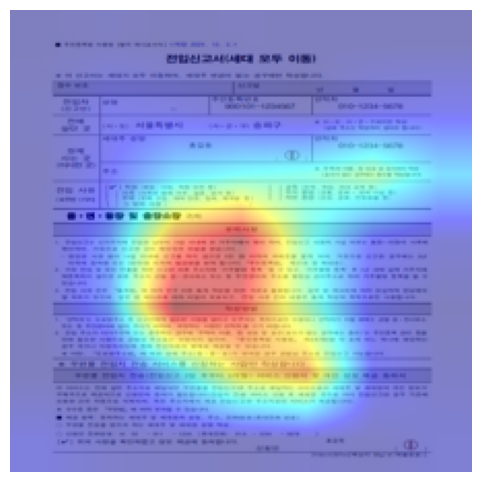

In [205]:
if input_tensor.dim() == 3:
    input_tensor = input_tensor.unsqueeze(0)

cam_input = input_tensor.clone().detach().float().to(device)
cam_input.requires_grad_(True)

cam = GradCAM(model=model, target_layers=target_layers)

target_label = 10   # 보고 싶은 클래스 번호

grayscale_cam = cam(
    input_tensor=cam_input,
    targets=[ClassifierOutputTarget(target_label)]
)

grad_cam = grayscale_cam[0]

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.figure(figsize=(6, 6))
plt.imshow(visualization)
plt.axis("off")
plt.show()